In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import math
from scipy.stats import norm
import matplotlib.pyplot as plt
import os

# [수정 1] 누락되었던 라이브러리 추가
from torch.distributions import Categorical, Normal

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import math
from scipy.stats import norm
import pandas as pd
import matplotlib.pyplot as plt
import os
from torch.distributions import Categorical, Normal

# ==========================================
# 0. Global Setup
# ==========================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"💻 Running on: {DEVICE}")

# ==========================================
# 1. Configuration
# ==========================================
CONFIG = {
    'h': 5.0,
    'b': 1000.0,
    'omega': 500.0,
    'CAP': 2000.0,
    'base_demand': 300.0,
    'days': 60,
    'tau_max': 7,
    'gamma': 1.0,
}

TRAIN_CONFIG = {
    'hidden_dim': 128,
    'supplier_emb_dim': 32,
    'num_layers': 3,
    'num_heads': 8
}

SUPPLIERS = {
    0: {'name': 'None', 'tau': 0, 'P': 0,   'MOQ': 0,    'C_cap': 1,    'C_ship': 0},
    1: {'name': 'A',    'tau': 7, 'P': 80,  'MOQ': 1000, 'C_cap': 2000, 'C_ship': 5000},
    2: {'name': 'B',    'tau': 5, 'P': 100, 'MOQ': 500,  'C_cap': 1000, 'C_ship': 3000},
    3: {'name': 'C',    'tau': 3, 'P': 120, 'MOQ': 200,  'C_cap': 1000, 'C_ship': 2000},
    4: {'name': 'D',    'tau': 1, 'P': 150, 'MOQ': 50,   'C_cap': 500,  'C_ship': 5000},
    5: {'name': 'E',    'tau': 0, 'P': 200, 'MOQ': 0,    'C_cap': 100,  'C_ship': 2000}
}

# ==========================================
# 2. Environment
# ==========================================
class VectorizedInventoryEnv:
    def __init__(self, config, batch_size):
        self.cfg = config
        self.batch_size = batch_size
        self.tau_max = config['tau_max']
        self.seasonal_month = torch.tensor([1.0, 1.0, 0.9, 1.0, 1.1, 1.2, 1.5, 1.5, 1.0, 0.9, 1.1, 1.3], device=DEVICE)
        self.seasonal_day = torch.tensor([1.2, 1.1, 1.0, 1.0, 0.9, 0.6, 0.5], device=DEVICE)

    def reset(self):
        self.on_hand = torch.rand(self.batch_size).to(DEVICE) * self.cfg['CAP']
        self.pipeline = torch.zeros(self.batch_size, self.tau_max + 1).to(DEVICE)
        start_day = torch.randint(0, 365 - self.cfg['days'], (1,)).item()
        self.t_global = start_day
        self.t_step = 0
        return self._get_state()

    def _get_state(self):
        inv_feat = self.on_hand.unsqueeze(1) / self.cfg['CAP']
        pipe_feat = self.pipeline[:, 1:] / self.cfg['CAP']
        sin_t = math.sin(2 * math.pi * self.t_global / 365)
        cos_t = math.cos(2 * math.pi * self.t_global / 365)
        time_feat = torch.tensor([[sin_t, cos_t]], device=DEVICE).repeat(self.batch_size, 1)
        state = torch.cat([inv_feat, pipe_feat, time_feat], dim=1)
        return state

    def _get_demand(self):
        current_month = (self.t_global // 30) % 12
        current_day = self.t_global % 7
        factor_m = self.seasonal_month[current_month]
        factor_d = self.seasonal_day[current_day]
        mu_t = self.cfg['base_demand'] * factor_m * factor_d
        sigma_t = mu_t * 0.2
        demand = torch.normal(mean=mu_t.float(), std=sigma_t.float(), size=(self.batch_size,)).to(DEVICE)
        return torch.clamp(demand, min=0).round().long()

    def step(self, supplier_idx, order_qty):
        cost_purch = torch.zeros(self.batch_size).to(DEVICE)
        cost_ship = torch.zeros(self.batch_size).to(DEVICE)
        instant_arrival = torch.zeros(self.batch_size).to(DEVICE)

        for s_code, s_info in SUPPLIERS.items():
            if s_code == 0: continue
            mask = (supplier_idx == s_code)
            if mask.sum() == 0: continue
            
            raw_qty = order_qty[mask]
            corrected_qty = torch.max(raw_qty, torch.tensor(float(s_info['MOQ']), device=DEVICE))
            order_qty[mask] = corrected_qty
            
            tau = s_info['tau']
            if tau == 0:
                instant_arrival[mask] += corrected_qty
            else:
                if tau <= self.tau_max:
                    self.pipeline[mask, tau] += corrected_qty
            
            cost_purch[mask] += corrected_qty * s_info['P']
            trucks = torch.ceil(corrected_qty / s_info['C_cap'])
            cost_ship[mask] += trucks * s_info['C_ship']

        arrived = self.pipeline[:, 1].clone() + instant_arrival
        self.pipeline[:, :-1] = self.pipeline[:, 1:].clone()
        self.pipeline[:, -1] = 0
        self.on_hand += arrived
        
        demands = self._get_demand()
        self.on_hand -= demands

        cost_hold = self.cfg['h'] * torch.relu(self.on_hand)
        cost_short = self.cfg['b'] * torch.relu(-self.on_hand)
        cost_over = self.cfg['omega'] * torch.relu(self.on_hand - self.cfg['CAP'])
        
        total_cost = cost_purch + cost_ship + cost_hold + cost_short + cost_over
        reward = -total_cost

        self.t_global += 1
        self.t_step += 1
        done = (self.t_step >= self.cfg['days'])
        
        info = {
            'demand': demands,
            'cost_vec': torch.stack([cost_purch, cost_ship, cost_hold, cost_short, cost_over], dim=1)
        }
        return self._get_state(), reward, done, info

# ==========================================
# 3. Model Architecture
# ==========================================
class InventoryTransformer(nn.Module):
    def __init__(self, state_dim, hidden_dim, num_layers=2, num_heads=4):
        super(InventoryTransformer, self).__init__()
        self.input_embed = nn.Linear(state_dim, hidden_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=num_heads, dim_feedforward=256, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.supplier_head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 6) 
        )
        self.sup_action_embed = nn.Embedding(6, TRAIN_CONFIG['supplier_emb_dim'])
        
        self.qty_input_dim = hidden_dim + TRAIN_CONFIG['supplier_emb_dim']
        self.qty_head_mu = nn.Sequential(
            nn.Linear(self.qty_input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )
        self.qty_head_sigma = nn.Sequential(
            nn.Linear(self.qty_input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Softplus()
        )
        self.qty_head_mu[2].bias.data.fill_(5.0) 

    def forward(self, state, fixed_supplier=None):
        x = self.input_embed(state).unsqueeze(1)
        features = self.transformer(x).squeeze(1)
        sup_logits = self.supplier_head(features)
        
        if fixed_supplier is not None:
            selected_sup = fixed_supplier
        else:
            selected_sup = torch.argmax(sup_logits, dim=1)
            
        sup_emb = self.sup_action_embed(selected_sup)
        qty_input = torch.cat([features, sup_emb], dim=1)
        mu = F.softplus(self.qty_head_mu(qty_input))
        sigma = self.qty_head_sigma(qty_input) + 1e-4
        return sup_logits, mu, sigma

    def act(self, state, deterministic=False):
        sup_logits, mu, sigma = self.forward(state)
        probs = F.softmax(sup_logits, dim=1)
        dist_s = Categorical(probs)
        
        if deterministic:
            supplier_idx = torch.argmax(probs, dim=1)
        else:
            supplier_idx = dist_s.sample()
            
        _, mu, sigma = self.forward(state, fixed_supplier=supplier_idx)
        dist_q = Normal(mu, sigma)
        
        if deterministic:
            quantity = mu
        else:
            quantity = dist_q.sample()
        
        quantity = torch.clamp(quantity, min=0.0)
        log_prob_s = dist_s.log_prob(supplier_idx) if not deterministic else None
        log_prob_q = dist_q.log_prob(quantity).sum(dim=-1) if not deterministic else None
        return supplier_idx, quantity.squeeze(-1), log_prob_s, log_prob_q

# ==========================================
# 4. Heuristic Agent
# ==========================================
class HeuristicBSP_Agent:
    def __init__(self, config, supplier_info):
        self.cfg = config
        self.target_supplier = supplier_info
        self.tau = self.target_supplier['tau']
        self.cr = config['b'] / (config['b'] + config['h'])
        avg_daily_demand = config['base_demand']
        std_daily_demand = config['base_demand'] * 0.2
        mu_L = avg_daily_demand * self.tau
        sigma_L = std_daily_demand * (self.tau ** 0.5)
        self.S = norm.ppf(self.cr, loc=mu_L, scale=sigma_L)
        
        print(f"📊 [Heuristic] Target Supplier: {supplier_info['name']}")
        print(f"📊 [Heuristic] Base-Stock Level (S): {self.S:.1f}")

    def act(self, state, env_instance):
        current_inv = env_instance.on_hand.item()
        pipeline_sum = env_instance.pipeline.sum().item()
        inv_position = current_inv + pipeline_sum
        
        if inv_position < self.S:
            order_qty = self.S - inv_position
            moq = self.target_supplier['MOQ']
            if order_qty < moq:
                order_qty = moq 
            supplier_idx = 1 # Supplier A
        else:
            order_qty = 0.0
            supplier_idx = 0 
            
        return (torch.tensor([supplier_idx], device=DEVICE), 
                torch.tensor([order_qty], dtype=torch.float32, device=DEVICE), 0, 0)

# ==========================================
# 5. Simulation Functions
# ==========================================
def run_detailed_simulation(agent, env_config, seed=42, agent_type='rl'):
    sim_days = 100
    temp_config = env_config.copy()
    temp_config['days'] = sim_days
    env = VectorizedInventoryEnv(temp_config, batch_size=1)
    
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    env.reset()
    env.on_hand = torch.tensor([300.0], device=DEVICE) # 초기 재고 300 설정
    state = env._get_state()
    
    log_data = []
    for t in range(sim_days):
        curr_inv = env.on_hand.item()
        curr_pipe = env.pipeline[0, 1:].tolist() 
        sin_t = math.sin(2 * math.pi * env.t_global / 365)
        cos_t = math.cos(2 * math.pi * env.t_global / 365)
        s_t_vec = [curr_inv] + curr_pipe + [sin_t, cos_t]
        
        if agent_type == 'heuristic':
            action_result = agent.act(state, env)
        else:
            action_result = agent.act(state, deterministic=True)
            
        sup_idx_tensor = action_result[0]
        qty_tensor = action_result[1]
        
        next_state, reward, done, info = env.step(sup_idx_tensor, qty_tensor)
        actual_sup = int(sup_idx_tensor.item())
        actual_qty = qty_tensor.item() 

        if actual_sup == 0:
            actual_qty = 0
        else:
            actual_qty = int(round(actual_qty))
            
        a_t_vec = [actual_sup, actual_qty]
        d_t_val = [int(info['demand'].item())]
        c_t_vec = [int(round(c)) for c in info['cost_vec'][0].tolist()]
        
        log_data.append({
            'TIME': t + 1,
            'S_t': s_t_vec,
            'A_t': a_t_vec,
            'D_t': d_t_val,
            'C_t': c_t_vec
        })
        state = next_state
    return log_data

def print_agent_table(log_data, title):
    def vec_to_str(vec):
        if isinstance(vec, list):
            return "[" + ", ".join([f"{int(x)}" if x == int(x) else f"{x:.1f}" for x in vec]) + "]"
        return str(vec)

    df = pd.DataFrame(log_data)
    cols_to_convert = ['S_t', 'A_t', 'D_t', 'C_t']
    for col in cols_to_convert:
        df[col] = df[col].apply(vec_to_str)
    
    pd.set_option('display.max_colwidth', None) 
    pd.set_option('display.width', 1000)
    print(f"\n📋 {title}")
    print("="*140)
    print(df[['TIME', 'S_t', 'A_t', 'D_t', 'C_t']].to_string(index=False, justify='left'))
    print("="*140)
    
    total_cost = sum([sum(d['C_t']) for d in log_data])
    print(f"💰 {title} Total Cumulative Cost: {total_cost:,.0f} Won\n")

# ==========================================
# 6. Main Execution
# ==========================================
if __name__ == "__main__":
    MODEL_PATH = "best_model_epoch_031_cost_35.pt" # 본인의 파일 경로에 맞게 수정하세요

    if not os.path.exists(MODEL_PATH):
        print(f"❌ Error: Model file not found at '{MODEL_PATH}'")
    else:
        print(f"📂 Loading model from: {MODEL_PATH}")
        state_dim = 1 + CONFIG['tau_max'] + 2 
        model = InventoryTransformer(
            state_dim=state_dim, 
            hidden_dim=TRAIN_CONFIG['hidden_dim'],
            num_layers=TRAIN_CONFIG['num_layers'], 
            num_heads=TRAIN_CONFIG['num_heads']    
        ).to(DEVICE)
        
        checkpoint = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True)
        model.load_state_dict(checkpoint)
        model.eval()

        heuristic_agent = HeuristicBSP_Agent(CONFIG, SUPPLIERS[1])
        TEST_SEED = 12345
        print("\n🚀 Starting Detailed Vector Simulation...")
        
        rl_logs = run_detailed_simulation(model, CONFIG, seed=TEST_SEED, agent_type='rl')
        bsp_logs = run_detailed_simulation(heuristic_agent, CONFIG, seed=TEST_SEED, agent_type='heuristic')
        
        print_agent_table(rl_logs, "[RL Agent] State-Action-Cost Log")
        print_agent_table(bsp_logs, "[Heuristic Agent] State-Action-Cost Log")

💻 Running on: cuda
📂 Loading model from: best_model_epoch_031_cost_35.pt
📊 [Heuristic] Target Supplier: A
📊 [Heuristic] Base-Stock Level (S): 2509.2

🚀 Starting Detailed Vector Simulation...

📋 [RL Agent] State-Action-Cost Log
 TIME S_t                                             A_t      D_t   C_t                        
  1             [300, 0, 0, 0, 0, 0, 0, 0, 0.2, -1.0] [2, 500] [458] [50000, 3000, 0, 158000, 0]
  2          [-158, 0, 0, 0, 500, 0, 0, 0, 0.2, -1.0] [2, 500] [287] [50000, 3000, 0, 445000, 0]
  3        [-445, 0, 0, 500, 500, 0, 0, 0, 0.2, -1.0] [2, 500] [278] [50000, 3000, 0, 723000, 0]
  4      [-723, 0, 500, 500, 500, 0, 0, 0, 0.1, -1.0] [2, 500] [159] [50000, 3000, 0, 882000, 0]
  5    [-882, 500, 500, 500, 500, 0, 0, 0, 0.1, -1.0] [2, 500] [397] [50000, 3000, 0, 779000, 0]
  6    [-779, 500, 500, 500, 500, 0, 0, 0, 0.1, -1.0] [2, 500] [333] [50000, 3000, 0, 612000, 0]
  7    [-612, 500, 500, 500, 500, 0, 0, 0, 0.1, -1.0] [2, 500] [327] [50000, 3000, 0, 439000, 

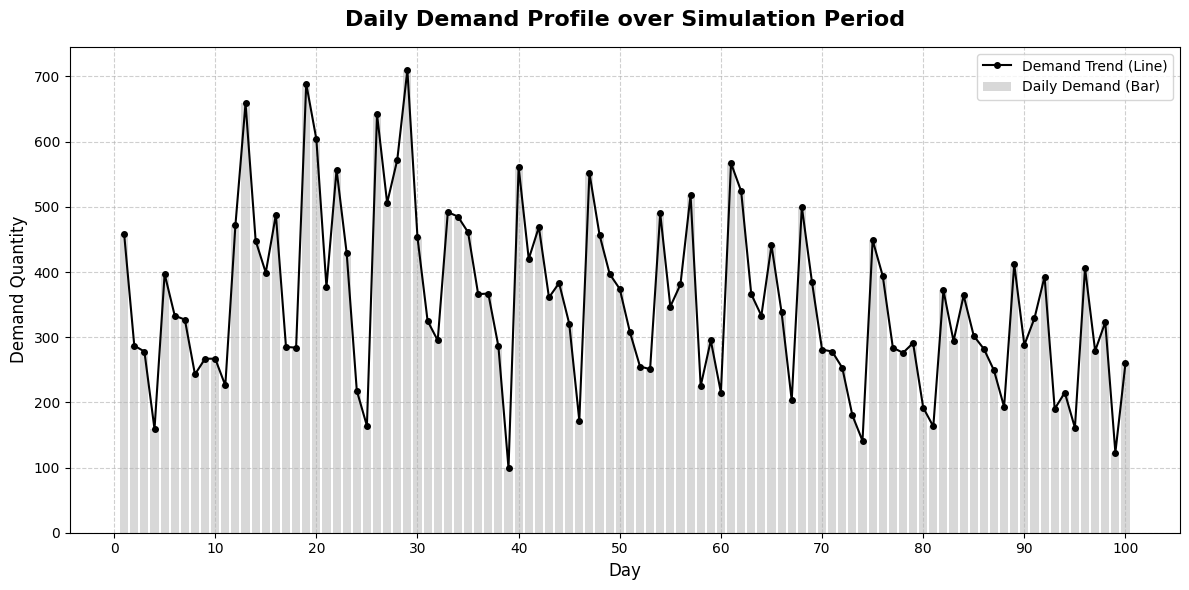

In [29]:
# @title 📈 Daily Demand (일일 수요) 단독 그래프 출력
import matplotlib.pyplot as plt

def plot_daily_demand_standalone(rl_logs):
    # 데이터 추출
    days = [log['TIME'] for log in rl_logs]
    daily_demand = [log['D_t'][0] for log in rl_logs]
    
    # 그래프 생성
    plt.figure(figsize=(12, 6))
    
    # 막대 그래프와 선 그래프를 결합하여 가독성 증대
    plt.bar(days, daily_demand, color='gray', alpha=0.3, label='Daily Demand (Bar)')
    plt.plot(days, daily_demand, color='black', marker='o', markersize=4, 
             linewidth=1.5, label='Demand Trend (Line)')
    
    # 그래프 타이틀 및 라벨 설정
    plt.title('Daily Demand Profile over Simulation Period', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Day', fontsize=12)
    plt.ylabel('Demand Quantity', fontsize=12)
    
    # 그리드 및 범례 설정
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='upper right', fontsize=10)
    
    # x축 눈금 최적화 (10일 단위)
    plt.xticks(range(0, len(days) + 1, 10))
    
    plt.tight_layout()
    plt.show()

# 실행 (rl_logs 또는 bsp_logs 어느 것을 넣어도 수요는 동일합니다)
plot_daily_demand_standalone(rl_logs)

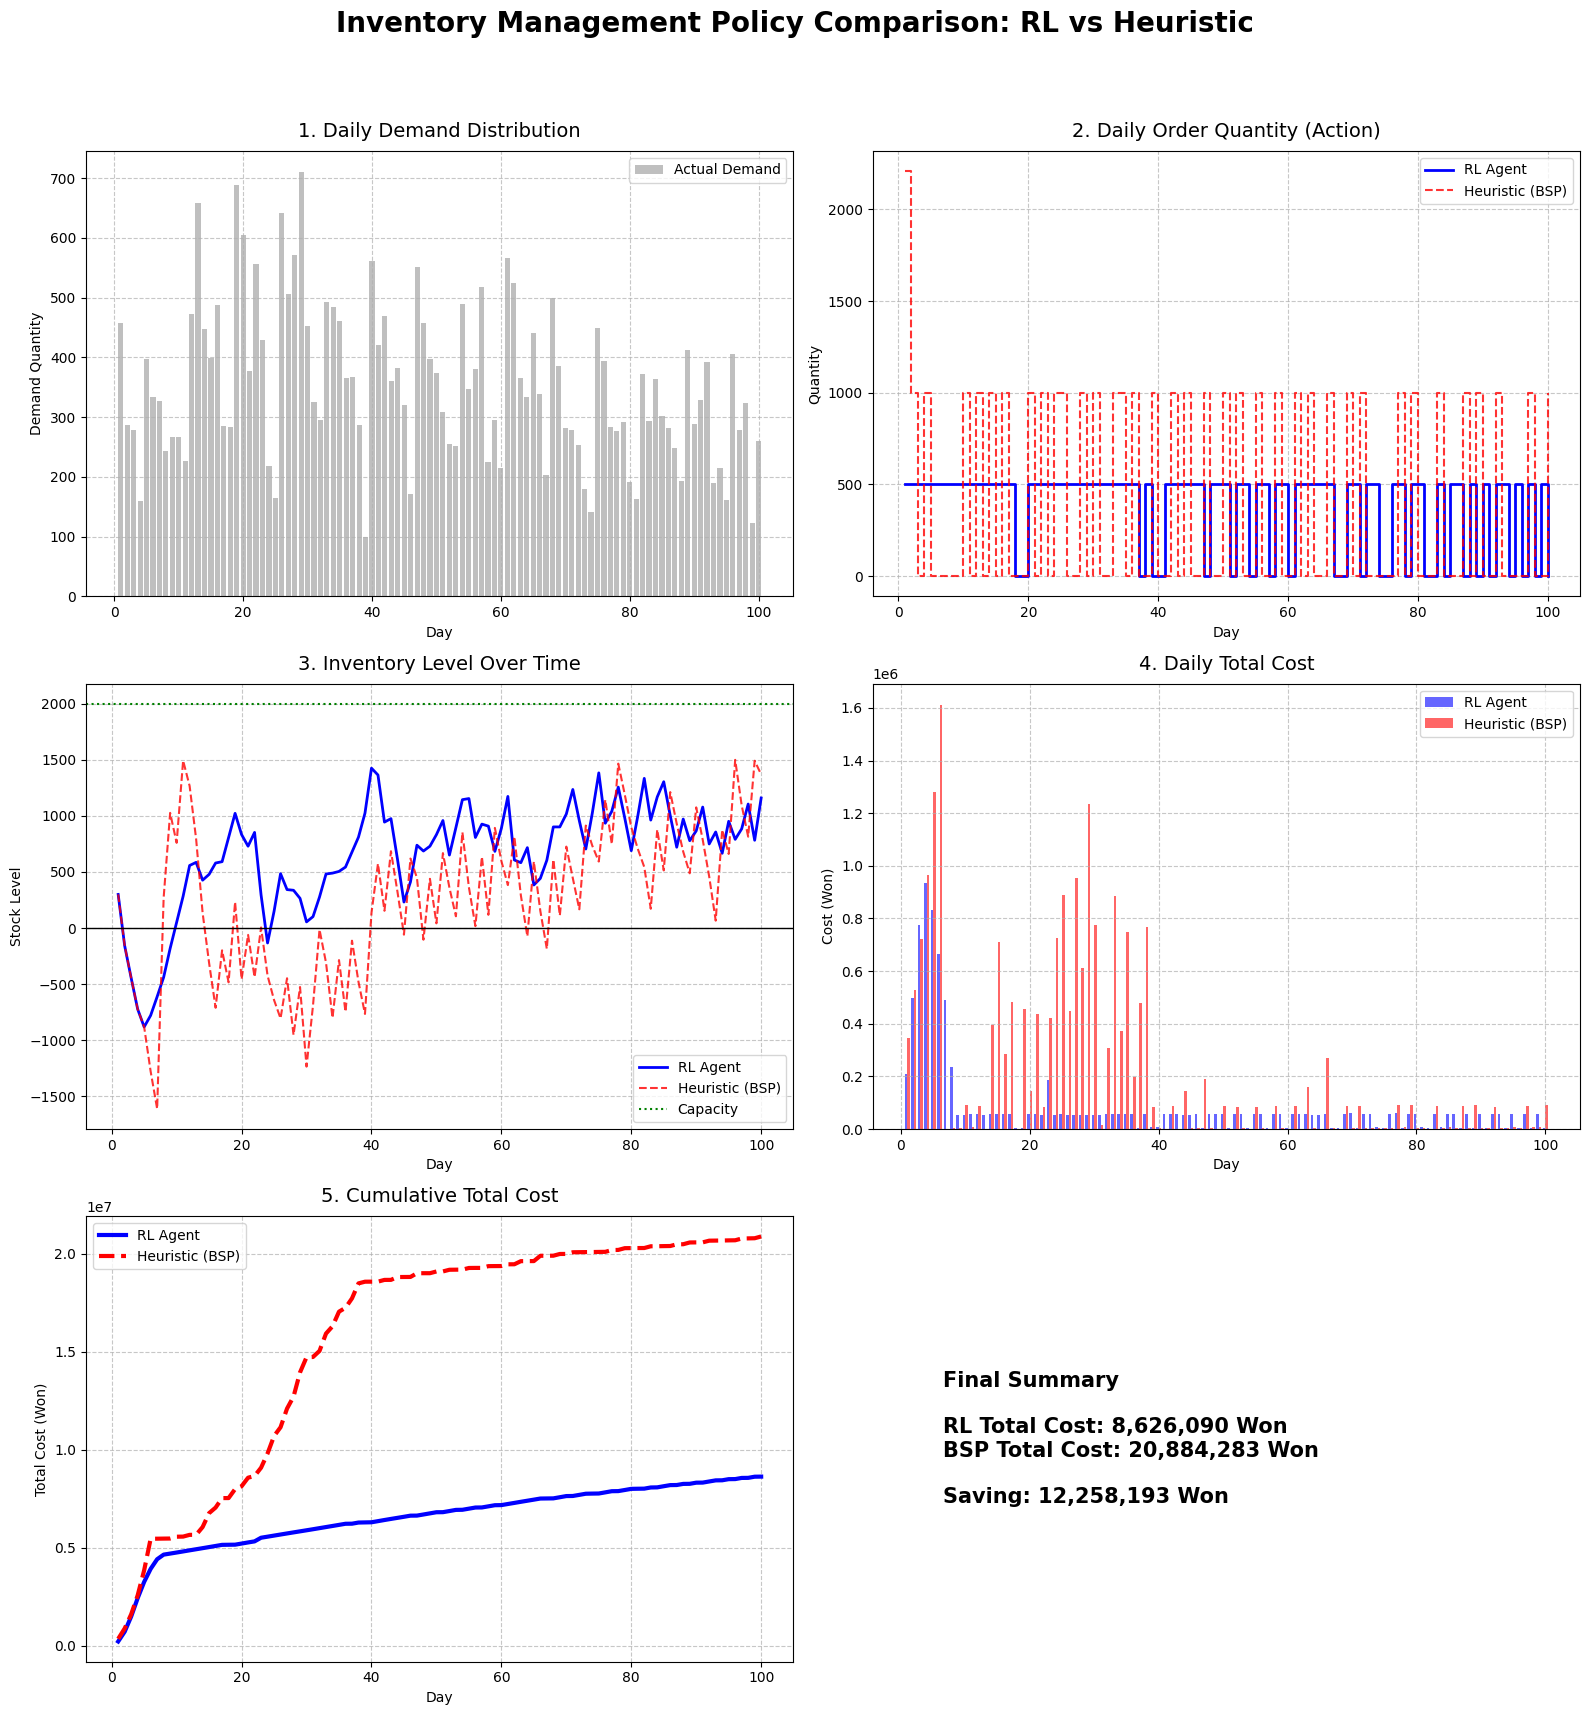

In [28]:
# @title 📊 RL 에이전트 vs 휴리스틱(BSP) 정책 비교 시각화 (수요 그래프 추가)
import matplotlib.pyplot as plt
import numpy as np

def plot_comparison_v2(rl_logs, bsp_logs):
    # 데이터 추출
    days = [log['TIME'] for log in rl_logs]
    
    # 공통 데이터 (수요는 두 에이전트가 동일함)
    daily_demand = [log['D_t'][0] for log in rl_logs]
    
    # RL 에이전트 데이터
    rl_inv = [log['S_t'][0] for log in rl_logs]
    rl_order = [log['A_t'][1] for log in rl_logs]
    rl_daily_cost = [sum(log['C_t']) for log in rl_logs]
    rl_cum_cost = np.cumsum(rl_daily_cost)
    
    # 휴리스틱(BSP) 에이전트 데이터
    bsp_inv = [log['S_t'][0] for log in bsp_logs]
    bsp_order = [log['A_t'][1] for log in bsp_logs]
    bsp_daily_cost = [sum(log['C_t']) for log in bsp_logs]
    bsp_cum_cost = np.cumsum(bsp_daily_cost)

    # 그래프 설정 (3행 2열 구성)
    fig, axs = plt.subplots(3, 2, figsize=(16, 18))
    fig.suptitle('Inventory Management Policy Comparison: RL vs Heuristic', fontsize=20, fontweight='bold')

    # 1. 매일 발생된 수요 (Daily Demand) - NEW!
    axs[0, 0].bar(days, daily_demand, color='gray', alpha=0.5, label='Actual Demand')
    axs[0, 0].set_title('1. Daily Demand Distribution', fontsize=14, pad=10)
    axs[0, 0].set_xlabel('Day')
    axs[0, 0].set_ylabel('Demand Quantity')
    axs[0, 0].legend()
    axs[0, 0].grid(True, linestyle='--', alpha=0.7)

    # 2. 매일의 주문량 (Order Quantity)
    axs[0, 1].step(days, rl_order, label='RL Agent', where='post', color='blue', linewidth=2)
    axs[0, 1].step(days, bsp_order, label='Heuristic (BSP)', where='post', color='red', linestyle='--', alpha=0.8)
    axs[0, 1].set_title('2. Daily Order Quantity (Action)', fontsize=14, pad=10)
    axs[0, 1].set_xlabel('Day')
    axs[0, 1].set_ylabel('Quantity')
    axs[0, 1].legend()
    axs[0, 1].grid(True, linestyle='--', alpha=0.7)

    # 3. 인벤토리 상황 (Inventory Level)
    axs[1, 0].plot(days, rl_inv, label='RL Agent', color='blue', linewidth=2)
    axs[1, 0].plot(days, bsp_inv, label='Heuristic (BSP)', color='red', linestyle='--', alpha=0.8)
    axs[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=1) # 품절선
    axs[1, 0].axhline(y=CONFIG['CAP'], color='green', linestyle=':', label='Capacity') # 용량선
    axs[1, 0].set_title('3. Inventory Level Over Time', fontsize=14, pad=10)
    axs[1, 0].set_xlabel('Day')
    axs[1, 0].set_ylabel('Stock Level')
    axs[1, 0].legend()
    axs[1, 0].grid(True, linestyle='--', alpha=0.7)

    # 4. 매일 비용 발생 (Daily Cost)
    axs[1, 1].bar(np.array(days)-0.2, rl_daily_cost, width=0.4, label='RL Agent', color='blue', alpha=0.6)
    axs[1, 1].bar(np.array(days)+0.2, bsp_daily_cost, width=0.4, label='Heuristic (BSP)', color='red', alpha=0.6)
    axs[1, 1].set_title('4. Daily Total Cost', fontsize=14, pad=10)
    axs[1, 1].set_xlabel('Day')
    axs[1, 1].set_ylabel('Cost (Won)')
    axs[1, 1].legend()
    axs[1, 1].grid(True, linestyle='--', alpha=0.7)

    # 5. 누적 비용 상황 (Cumulative Cost)
    axs[2, 0].plot(days, rl_cum_cost, label='RL Agent', color='blue', linewidth=3)
    axs[2, 0].plot(days, bsp_cum_cost, label='Heuristic (BSP)', color='red', linestyle='--', linewidth=3)
    axs[2, 0].set_title('5. Cumulative Total Cost', fontsize=14, pad=10)
    axs[2, 0].set_xlabel('Day')
    axs[2, 0].set_ylabel('Total Cost (Won)')
    axs[2, 0].legend()
    axs[2, 0].grid(True, linestyle='--', alpha=0.7)

    # 마지막 칸(2, 1)은 비워두거나 요약 텍스트를 넣을 수 있습니다.
    axs[2, 1].axis('off')
    summary_text = (
        f"Final Summary\n\n"
        f"RL Total Cost: {rl_cum_cost[-1]:,.0f} Won\n"
        f"BSP Total Cost: {bsp_cum_cost[-1]:,.0f} Won\n\n"
        f"Saving: {bsp_cum_cost[-1] - rl_cum_cost[-1]:,.0f} Won"
    )
    axs[2, 1].text(0.1, 0.5, summary_text, fontsize=15, fontweight='bold', verticalalignment='center')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# 그래프 실행
plot_comparison_v2(rl_logs, bsp_logs)